<a href="https://colab.research.google.com/github/DarcyAguiar/data_science/blob/master/Analisando_os_Dados_do_Airbnb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img alt="Colaboratory logo" width="15%" src="https://raw.githubusercontent.com/carlosfab/escola-data-science/master/img/novo_logo_bg_claro.png">

#### **Data Science na Prática 3.0**
*by [sigmoidal.ai](https://sigmoidal.ai)*

---

# Análise dos Dados do Airbnb - *Paris*

O [Airbnb](https://www.airbnb.com.br/) já é considerado como sendo a **maior empresa hoteleira da atualidade**. Ah, o detalhe é que ele **não possui nenhum hotel**!

Conectando pessoas que querem viajar (e se hospedar) com anfitriões que querem alugar seus imóveis de maneira prática, o Airbnb fornece uma plataforma inovadora para tornar essa hospedagem alternativa.

No final de 2018, a Startup fundada 10 anos atrás, já havia **hospedado mais de 300 milhões** de pessoas ao redor de todo o mundo, desafiando as redes hoteleiras tradicionais.

Uma das iniciativas do Airbnb é disponibilizar dados do site, para algumas das principais cidades do mundo. Por meio do portal [Inside Airbnb](http://insideairbnb.com/get-the-data.html), é possível baixar uma grande quantidade de dados para desenvolver projetos e soluções de *Data Science*.

<center><img alt="Analisando Airbnb" width="10%" src="https://www.area360.com.au/wp-content/uploads/2017/09/airbnb-logo.jpg"></center>

**Neste *notebook*, iremos analisar os dados referentes à cidade Paris, e ver quais insights podem ser extraídos a partir de dados brutos.**

## Obtenção dos Dados


In [1]:
# importar os pacotes necessarios
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
# importar o arquivo listings.csv para um DataFrame
df = pd.read_csv('https://raw.githubusercontent.com/DarcyAguiar/data_science/master/Paris%2C%20%C3%8Ele-de-France%2C%20France.csv')

## Análise dos Dados


**Dicionário das variáveis**

* *id* - número gerado para identificar o imovel
* *name* - nome do local alugado
* *host_id* - número gereado para identificar proprietário do local
* *host_name* - nome do proprietário do imóvel
* *neighbourhood_group* - Esta coluna não está preenchida
* *neighbourhood* - bairro onde está localizado o imóvel
* *latitude/longitude* - coordenada do imóvel
* *room_type* - tipo de quarto
* *price* - preço do aluguel do imóvel 
* *minimum_nights* - quantidade mínima de noites para reserva 
* *number_of_reviews* - quantidade de reviews que o imóvel possui
* *last_review* - ultimo review do imóvel
* *reviews_per_month* - reviews por mês
* *calculated_host_listings_count* - quantidade de imóveis do mesmo proprietário
* *availability_365* - número de dias diponiveis em um ano
* *number_of_reviews_ltm* - numero de reviews nos últimos 12 meses
* *license* - contrato de arrendamento

Antes de iniciar qualquer análise, vamos verificar a cara do nosso *dataset*, analisando as 5 primeiras entradas.

In [3]:
# mostrar as 5 primeiras entradas
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,5396,Explore the heart of old Paris,7903,Borzou,NaN,Hôtel-de-Ville,48.85247,2.35835,Entire home/apt,80,2,277,2022-01-04,1.82,1,66,45,7510402838018
1,7397,MARAIS - 2ROOMS APT - 2/4 PEOPLE,2626,Franck,NaN,Hôtel-de-Ville,48.85909,2.35315,Entire home/apt,105,10,290,2021-12-30,2.21,4,212,20,7510400829623
2,7964,Large & sunny flat with balcony !,22155,Anaïs,NaN,Opéra,48.87417,2.34245,Entire home/apt,130,6,6,2015-09-14,0.04,1,365,0,7510903576564
3,9359,"Cozy, Central Paris: WALK or VELIB EVERYWHERE !",28422,Bernadette,NaN,Louvre,48.86006,2.34863,Entire home/apt,75,180,0,NaN,NaN,1,148,0,"Available with a mobility lease only (""bail mo..."
4,9952,Paris petit coin douillet,33534,Elisabeth,NaN,Popincourt,48.86373,2.37093,Entire home/apt,80,4,34,2021-12-28,0.32,1,212,8,7511101582862


### **Q1. Quantos atributos (variáveis) e quantas entradas o nosso conjunto de dados possui? Quais os tipos das variáveis?**

In [4]:
# identificar o volume de dados do DataFrame
print('Entradas:{}'.format(df.shape[0]))
print('Variáveis:{}\n'.format(df.shape[1]))
print('Tipo das Variáveis:\n{}'.format(df.dtypes))
# verificar as 5 primeiras entradas do dataset
df.head()


Entradas:49255
Variáveis:18

Tipo das Variáveis:
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group               float64
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
number_of_reviews_ltm               int64
license                            object
dtype: object


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,5396,Explore the heart of old Paris,7903,Borzou,NaN,Hôtel-de-Ville,48.85247,2.35835,Entire home/apt,80,2,277,2022-01-04,1.82,1,66,45,7510402838018
1,7397,MARAIS - 2ROOMS APT - 2/4 PEOPLE,2626,Franck,NaN,Hôtel-de-Ville,48.85909,2.35315,Entire home/apt,105,10,290,2021-12-30,2.21,4,212,20,7510400829623
2,7964,Large & sunny flat with balcony !,22155,Anaïs,NaN,Opéra,48.87417,2.34245,Entire home/apt,130,6,6,2015-09-14,0.04,1,365,0,7510903576564
3,9359,"Cozy, Central Paris: WALK or VELIB EVERYWHERE !",28422,Bernadette,NaN,Louvre,48.86006,2.34863,Entire home/apt,75,180,0,NaN,NaN,1,148,0,"Available with a mobility lease only (""bail mo..."
4,9952,Paris petit coin douillet,33534,Elisabeth,NaN,Popincourt,48.86373,2.37093,Entire home/apt,80,4,34,2021-12-28,0.32,1,212,8,7511101582862


### **Q2. Qual a porcentagem de valores ausentes no *dataset*?**
Ao *analisar* esse dataset podemos ver que algumas variáveis estão com valores ausentes. Sabendo disso, devemos averiguar o quão significativo é para sabermos como tratar esses dados.

* Podemos ver que a coluna `neighbourhood_group` possui 100% dos seus valores faltantes.
* A coluna `license` possui valores ausentes em quase metade das linhas
*As variáveis `reviews_per_month` e `last_review` tem aproximadamente 20% dos 
valores ausentes.


In [5]:
# ordenar em ordem decrescente as variáveis por seus valores ausentes
(df.isnull().sum() / df.shape[0] * 100).sort_values(ascending=False)


neighbourhood_group               100.000000
license                            42.793625
reviews_per_month                  20.818191
last_review                        20.818191
name                                0.087301
host_name                           0.056847
number_of_reviews                   0.000000
number_of_reviews_ltm               0.000000
availability_365                    0.000000
calculated_host_listings_count      0.000000
id                                  0.000000
minimum_nights                      0.000000
room_type                           0.000000
longitude                           0.000000
latitude                            0.000000
neighbourhood                       0.000000
host_id                             0.000000
price                               0.000000
dtype: float64

### **Q3. Qual o tipo de distribuição das variáveis?** 

Para identificar a distribuição das variáveis, irei plotar o histograma.

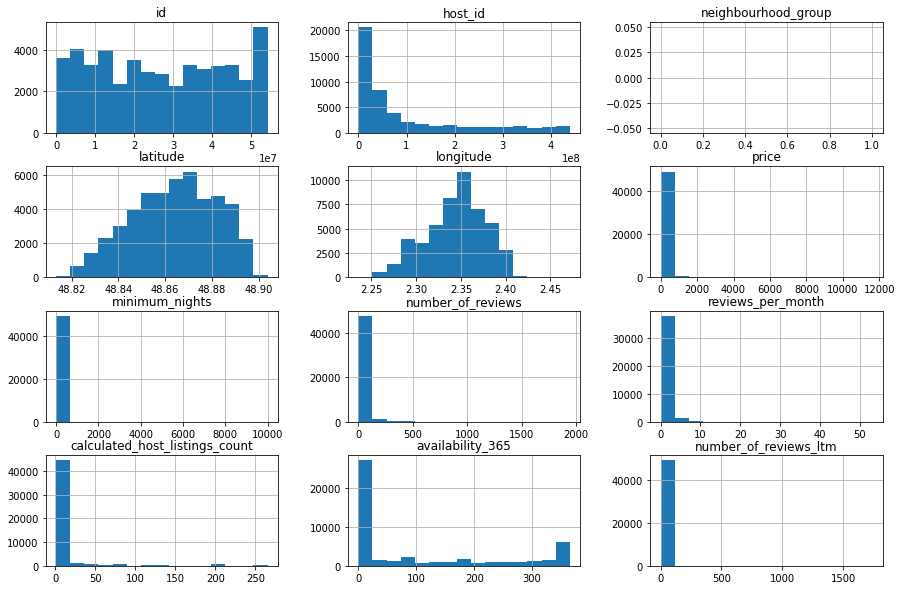

In [6]:
# plotar o histograma das variáveis numéricas
df.hist(bins=15, figsize=(15,10));

### **Q4. Há *outliers* presentes?**
Pelo que podemos ver no histograma, as variáveis `minimum_nights`, `price` e `calculated_host_listings_count` tem indícios de *Outliers*, pois os valores distorcem a representação do histograma. Podemos utilizar o método *describre* e o grafico boxplot para nos auxiliar na detecção de *outliers*

* Resumo estatístico por meio do método `describe()`
* Plotar `boxplots` para a variável.

In [7]:
#Para vermos o resumo estatístico das variáveis numéricas
df[['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']].describe()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,49255.000000,49255.000000,49255.000000,39001.000000,49255.000000,49255.000000
mean,128.662958,107.989524,22.001746,0.803106,9.883118,103.157629
std,228.886467,168.112081,46.790986,1.181524,33.269320,136.944962
min,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,60.000000,2.000000,1.000000,0.120000,1.000000,0.000000
50%,90.000000,4.000000,6.000000,0.380000,1.000000,3.000000
75%,135.000000,365.000000,22.000000,1.000000,2.000000,208.000000
max,11600.000000,9999.000000,1943.000000,53.040000,265.000000,365.000000


Com o resumo estatístico acima, podemos confirmar algumas hipóteses como: 
* A variável `price` possui 75% do valor abaixo de 365, e o seu valor máximo é 11600.
* A quantidade mínima de noites `minimum_nights` está acima de 365 dias no ano.
* A quantidade maxima de imóvel para o mesmo anfitrião `calculated_host_listings_count` é 265.

#### Boxplot para minimum_nights

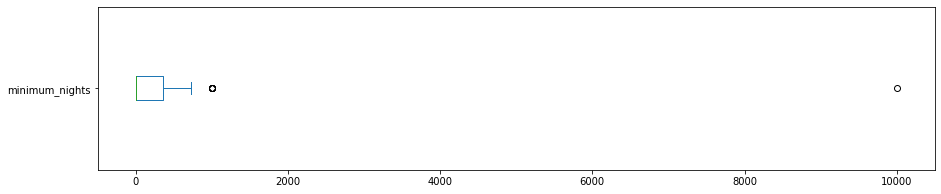

minimum_nights: valores acima de 30:
14681 entradas
29.81%


In [8]:
df.minimum_nights.plot(kind='box', vert=False, figsize=(15, 3))
plt.show()

#ver quantidade de valores acima de 30 dias para minimum_nights
print("minimum_nights: valores acima de 30:")
print("{} entradas".format(len(df[df.minimum_nights > 30])))
print("{:.4}%".format((len(df[df.minimum_nights > 30]) / df.shape[0])*100))

#### Boxplot para price

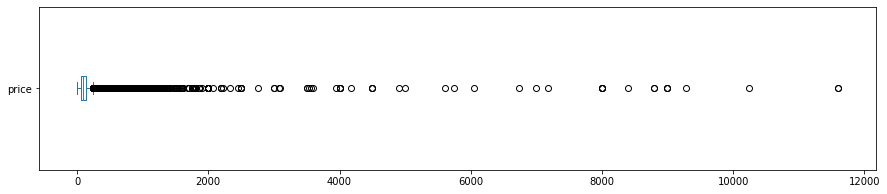

price: valores acima de 1000
257 entradas
0.5218%


In [9]:
#price
df.price.plot(kind='box', vert=False, figsize=(15, 3))
plt.show()

#ver quantidade de valores acima de 1000 para price
print('price: valores acima de 1000')
print('{} entradas'.format(len(df[df.price > 1000])))
print("{:.4f}%".format((len(df[df.price > 1000]) / df.shape[0])*100))

#### Boxplot para calculated_host_listings_count

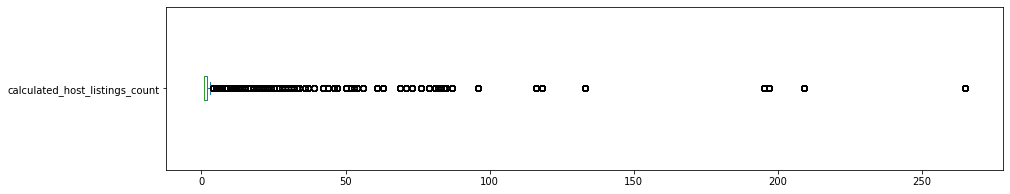

calculated_host_listings_count: valores acima de 10:
5474 entradas
11.11%


In [10]:
df.calculated_host_listings_count.plot(kind='box', vert=False, figsize=(15, 3))
plt.show()

#ver quantidade de valores acima de 10 para calculated_host_listings_count
print("calculated_host_listings_count: valores acima de 10:")
print("{} entradas".format(len(df[df.calculated_host_listings_count > 10])))
print("{:.4}%".format((len(df[df.calculated_host_listings_count > 10]) / df.shape[0])*100))

#### Histogramas sem *outliers*

Como identificamos *outliers* nas variáveis `price`, `calculated_host_listings_count` e `minimum_nights`, vamos limpar o *DataFrame* e plotar novamente.

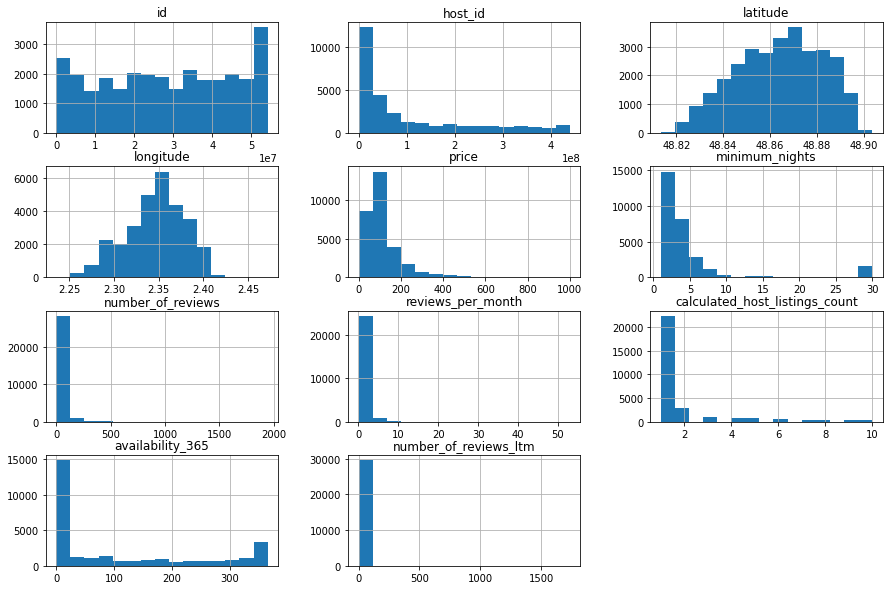

In [11]:
# remover os outliers e passar para um novo DataFrame
df_clean = df.copy()
df_clean.drop(df_clean[df_clean.price > 1000].index, axis=0, inplace=True)
df_clean.drop(df_clean[df_clean.minimum_nights > 30].index, axis=0, inplace=True)
df_clean.drop(df_clean[df_clean.calculated_host_listings_count > 10].index, axis=0, inplace=True)

#remover coluna neighbourhood_group, pois está vazio
df_clean.drop('neighbourhood_group', axis=1, inplace=True)

#Plotar histograma
df_clean.hist(bins=15, figsize=(15,10));

### **Q5. Qual a média dos preços de aluguel?**

In [12]:
# ver a média da coluna `price``
print('a média dos preços de aluguel é: {:.2f}'.format(df_clean.price.mean()))


a média dos preços de aluguel é: 117.27


### **Q6. Qual a correlação existente entre as variáveis**

In [13]:
# criar uma matriz de correlação
corr = df_clean[['price','minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']].corr()

# mostrar a matriz de correlação
display(corr)


,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
price,1.000000,-0.066367,-0.009972,-0.003042,0.227020,0.254229
minimum_nights,-0.066367,1.000000,-0.043453,-0.129038,-0.074200,0.072071
number_of_reviews,-0.009972,-0.043453,1.000000,0.601899,0.015959,0.132830
reviews_per_month,-0.003042,-0.129038,0.601899,1.000000,0.154370,0.225711
calculated_host_listings_count,0.227020,-0.074200,0.015959,0.154370,1.000000,0.355525
availability_365,0.254229,0.072071,0.132830,0.225711,0.355525,1.000000


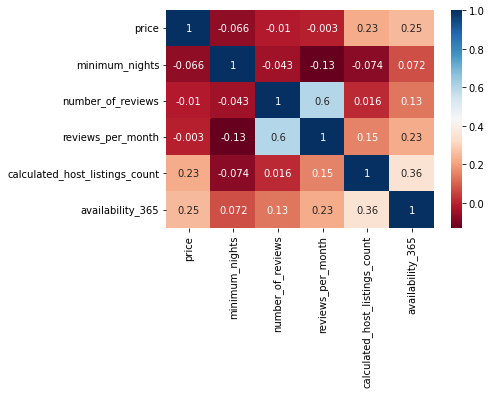

In [14]:
# plotar um heatmap a partir das correlações
sns.heatmap(corr, cmap='RdBu', annot=True);

### **Q7. Qual o tipo de imóvel mais alugado no Airbnb?**
O imóvel mais alugado no Airbnb é *casa/apartamento*, seguindo dos *quartos privativos*, *quarto de hotel* e por ultimo *quartos compartilhados*.



In [15]:
# mostrar a quantidade de cada tipo de imóvel disponível
df_clean.room_type.value_counts() 


Entire home/apt    21680
Private room        6685
Hotel room           929
Shared room          294
Name: room_type, dtype: int64

In [16]:
# mostrar a porcentagem de cada tipo de imóvel disponível
df_clean.room_type.value_counts() / df_clean.shape[0] * 100

Entire home/apt    73.272948
Private room       22.593619
Hotel room          3.139786
Shared room         0.993646
Name: room_type, dtype: float64

### **Q8. Qual a localidade mais cara do dataset?**



In [17]:
# ver preços por bairros, na média
df_clean.groupby(['neighbourhood']).price.mean().sort_values(ascending=False)

neighbourhood
Élysée                 194.565901
Luxembourg             171.680525
Louvre                 168.609422
Hôtel-de-Ville         166.741453
Palais-Bourbon         160.612081
Passy                  155.716841
Temple                 144.506394
Panthéon               139.069061
Opéra                  137.703095
Bourse                 137.006296
Batignolles-Monceau    111.653954
Vaugirard              110.762613
Entrepôt               106.918759
Popincourt              99.816121
Observatoire            97.364486
Buttes-Montmartre       95.375763
Reuilly                 92.453426
Gobelins                89.570796
Buttes-Chaumont         82.054771
Ménilmontant            78.484241
Name: price, dtype: float64

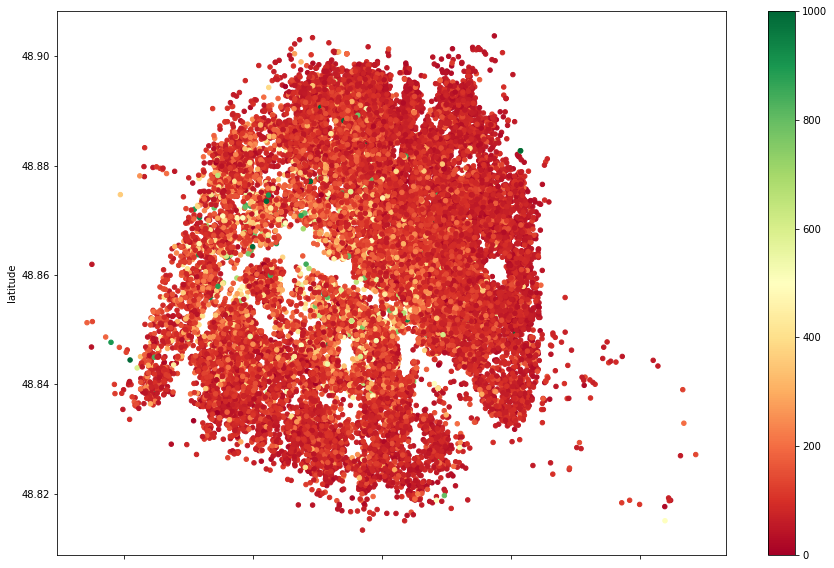

In [18]:
# plotar os imóveis pela latitude-longitude
df_clean.plot.scatter(y='latitude', x='longitude', c=df_clean['price'], cmap='RdYlGn', figsize=(15,10));

### **Q9. Qual é a média do mínimo de noites para aluguel (minimum_nights)?**

In [19]:
# ver a média da coluna `minimum_nights``
print('A média do minimo de noites para aluguel é: {}'.format(df_clean.minimum_nights.mean()))


A média do minimo de noites para aluguel é: 4.537380018926592


## Conclusões


Foi realizado uma análise exploratória superficial na base de dados do Airbnb da cidade de Paris na França, onde foi indentificado e tratado alguns *outliers* em suas variáveis. Por fim, é importante lembrar que este dataset é uma versão resumida, sendo o ideal para uma abordagem inicial de análise. Para uma análise exploratória mais profunda recomanda-se que seja realizado em um dataset completo